In [1]:
import sys
sys.path.insert(0, '/home/565/zr7147/Proj')

import numpy as np
import matplotlib.pyplot as plt

from scripts.mse_budget import load_dataset, _mse, _dse, _vadv_col, _col_int_p, CP, G, LV

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'figure.facecolor': 'white',
})

TOP_COLOR = '#d62728'
BOT_COLOR = '#1f77b4'

---
## Step 1 — Load Real BEACH L4 Profiles

Load the BEACH Level 4 dataset — circle-mean profiles derived from HALO dropsonde circles. The most top-heavy and most bottom-heavy circles (by `top_heaviness_angle`) are selected as samples.

In [4]:
ds  = load_dataset()
alt = ds['altitude'].values          # metres
nz  = len(alt)

# Select most extreme top-heavy and bottom-heavy circles
th_angle = ds['top_heaviness_angle'].values
i_th = int(np.nanargmax(th_angle))
i_bh = int(np.nanargmin(th_angle))

t_th = str(ds['circle_time'].values[i_th])[:16]
t_bh = str(ds['circle_time'].values[i_bh])[:16]

# Extract all profiles for both circles
T_th     = ds['ta_mean'].values[i_th];   T_bh     = ds['ta_mean'].values[i_bh]
q_th     = ds['q_mean'].values[i_th];    q_bh     = ds['q_mean'].values[i_bh]
p_th     = ds['p_mean'].values[i_th];    p_bh     = ds['p_mean'].values[i_bh]
omega_th = ds['omega'].values[i_th];     omega_bh = ds['omega'].values[i_bh]
div_th   = ds['div'].values[i_th];       div_bh   = ds['div'].values[i_bh]

print(f"Vertical grid: {nz} levels, 0 to {alt[-1]/1000:.1f} km, spacing 10 m")
print(f"Tropopause ≈ 17 km — profiles are {17 - alt[-1]/1000:.1f} km short!\n") #assumes tropopause at 17km
print(f"Top-Heavy example:    circle {i_th}, {t_th} UTC  (angle = {th_angle[i_th]:.2f})")
print(f"Bottom-Heavy example: circle {i_bh}, {t_bh} UTC  (angle = {th_angle[i_bh]:.2f})")

Vertical grid: 1460 levels, 0 to 14.6 km, spacing 10 m
Tropopause ≈ 17 km — profiles are 2.4 km short!

Top-Heavy example:    circle 44, 2024-09-07T15:21 UTC  (angle = 179.98)
Bottom-Heavy example: circle 37, 2024-08-31T14:46 UTC  (angle = -179.32)


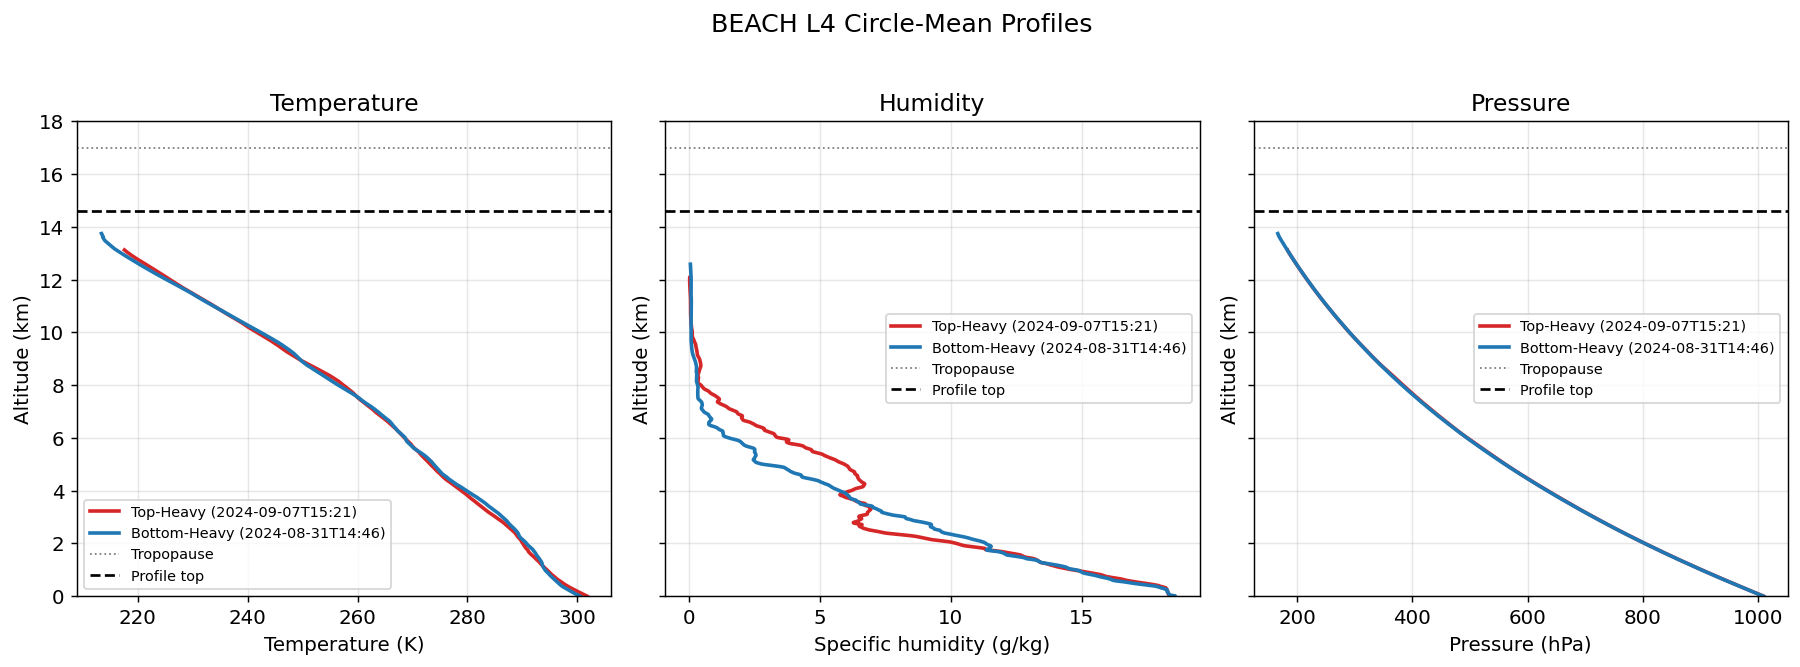

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for T, q, p, col, lbl in [
    (T_th, q_th, p_th, TOP_COLOR, f'Top-Heavy ({t_th})'),
    (T_bh, q_bh, p_bh, BOT_COLOR, f'Bottom-Heavy ({t_bh})'),
]:
    axes[0].plot(T, alt/1000, color=col, lw=2, label=lbl)
    axes[1].plot(q*1000, alt/1000, color=col, lw=2, label=lbl)
    axes[2].plot(p/100, alt/1000, color=col, lw=2, label=lbl)

for ax, xlabel, title in [
    (axes[0], 'Temperature (K)', 'Temperature'),
    (axes[1], 'Specific humidity (g/kg)', 'Humidity'),
    (axes[2], 'Pressure (hPa)', 'Pressure'),
]:
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Altitude (km)')
    ax.set_title(title)
    ax.axhline(17, color='gray', ls=':', lw=1, label='Tropopause')
    ax.axhline(alt[-1]/1000, color='k', ls='--', lw=1.5, label='Profile top')
    ax.set_ylim(0, 18)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('BEACH L4 Circle-Mean Profiles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 2 — Compute MSE and DSE

$$h = c_p T + gz + L_v q \qquad s = c_p T + gz$$

The MSE profile has a characteristic **C-shape** in the tropics: high at the surface (warm + moist), a minimum around 4–5 km (moisture gone but $gz$ not yet large), and rising again aloft ($gz$ dominates)

In [8]:
# Compute MSE and DSE from real profiles
h_th = _mse(T_th, alt, q_th)
s_th = _dse(T_th, alt)
h_bh = _mse(T_bh, alt, q_bh)
s_bh = _dse(T_bh, alt)

# Decompose top-heavy profile for illustration
h_sens = CP * T_th
h_pot  = G  * alt
h_lat  = LV * q_th

i_min = int(np.nanargmin(h_th))

print("=" * 60)
print("MSE DECOMPOSITION  (Top-Heavy circle)")
print("=" * 60)
print(f"Surface: h = {h_th[0]/1000:.1f} kJ/kg  =  cpT({h_sens[0]/1000:.1f}) + gz({h_pot[0]/1000:.1f}) + Lvq({h_lat[0]/1000:.1f})")
print(f"Top:     h = {h_th[-1]/1000:.1f} kJ/kg  =  cpT({h_sens[-1]/1000:.1f}) + gz({h_pot[-1]/1000:.1f}) + Lvq({h_lat[-1]/1000:.1f})")
print(f"MSE minimum at {alt[i_min]/1000:.1f} km  (h = {h_th[i_min]/1000:.1f} kJ/kg)")
print()
print(f">>> h is of order {np.nanmean(h_th):.2e} J/kg — remember this number!")
print(f">>> If ω_top = 0.05 Pa/s → boundary term = {h_th[-1]*0.05/G:.0f} W/m²")
print(f">>> Physical signal ≈ 100–200 W/m²  →  ratio = {h_th[-1]*0.05/G / 150:.1f}×  Problem here!")

MSE DECOMPOSITION  (Top-Heavy circle)
Surface: h = 349.0 kJ/kg  =  cpT(303.0) + gz(0.0) + Lvq(46.1)
Top:     h = nan kJ/kg  =  cpT(nan) + gz(143.1) + Lvq(nan)
MSE minimum at 2.8 km  (h = 330.8 kJ/kg)

>>> h is of order 3.39e+05 J/kg — remember this number!
>>> If ω_top = 0.05 Pa/s → boundary term = nan W/m²
>>> Physical signal ≈ 100–200 W/m²  →  ratio = nan×  Problem here!


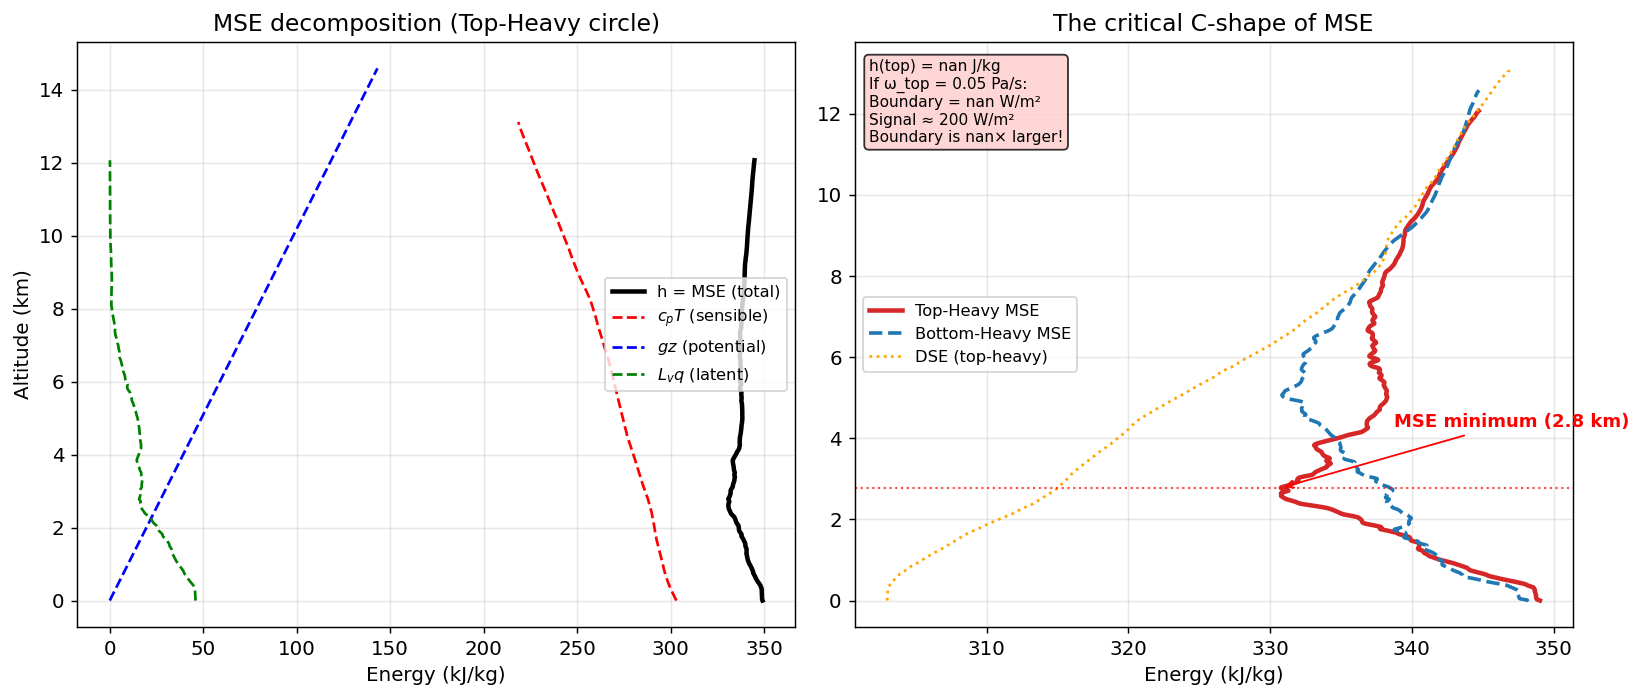

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: MSE decomposition
ax = axes[0]
ax.plot(h_th/1000,   alt/1000, 'k',  lw=2.5, label='h = MSE (total)')
ax.plot(h_sens/1000, alt/1000, 'r',  lw=1.5, ls='--', label=r'$c_p T$ (sensible)')
ax.plot(h_pot/1000,  alt/1000, 'b',  lw=1.5, ls='--', label=r'$gz$ (potential)')
ax.plot(h_lat/1000,  alt/1000, 'g',  lw=1.5, ls='--', label=r'$L_v q$ (latent)')
ax.set_xlabel('Energy (kJ/kg)');  ax.set_ylabel('Altitude (km)')
ax.set_title('MSE decomposition (Top-Heavy circle)')
ax.legend(fontsize=9, loc='center right');  ax.grid(True, alpha=0.3)

# Right: MSE C-shape for both circles
ax = axes[1]
ax.plot(h_th/1000, alt/1000, color=TOP_COLOR, lw=2.5, label='Top-Heavy MSE')
ax.plot(h_bh/1000, alt/1000, color=BOT_COLOR, lw=2,   ls='--', label='Bottom-Heavy MSE')
ax.plot(s_th/1000, alt/1000, color='orange',  lw=1.5, ls=':',  label='DSE (top-heavy)')
ax.axhline(alt[i_min]/1000, color='red', ls=':', lw=1.2, alpha=0.7)
ax.annotate(f'MSE minimum ({alt[i_min]/1000:.1f} km)',
            xy=(h_th[i_min]/1000, alt[i_min]/1000),
            xytext=(h_th[i_min]/1000 + 8, alt[i_min]/1000 + 1.5),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')
ax.set_xlabel('Energy (kJ/kg)');  ax.set_title('The critical C-shape of MSE')
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

ax.text(0.02, 0.97, f'h(top) = {h_th[-1]:.0f} J/kg\n'
        f'If ω_top = 0.05 Pa/s:\n'
        f'Boundary = {h_th[-1]*0.05/G:.0f} W/m²\n'
        f'Signal ≈ 200 W/m²\n'
        f'Boundary is {h_th[-1]*0.05/G / 200:.0f}× larger!',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8))

plt.tight_layout();  plt.show()

---
## Step 3 — Omega Profiles: Top-Heavy vs Bottom-Heavy

We use the omega profiles from the BEACH L4 dataset. These are derived by integrating the circle-mean divergence upward from the surface (ω = 0 at the surface). Because dropsonde circles end around 14.5 km — well below the tropopause at ~17 km — ω does **not** return to zero at the profile top.

In [13]:
def _top_idx(omega, h, p):
    """Index of the highest level where omega, h, and p are all finite."""
    valid = np.isfinite(omega) & np.isfinite(h) & np.isfinite(p)
    return np.where(valid)[0][-1]

itop_th = _top_idx(omega_th, h_th, p_th)
itop_bh = _top_idx(omega_bh, h_bh, p_bh)

dhdz = np.gradient(h_th, alt)

print("=" * 65)
print("OMEGA PROFILE DIAGNOSTICS (BEACH L4)")
print("=" * 65)
print(f"{'':>20} {'Top-Heavy':>14} {'Bottom-Heavy':>14}")
print("-" * 50)
print(f"{'ω at surface':>20} {omega_th[0]:>+14.6f} {omega_bh[0]:>+14.6f}  Pa/s")
print(f"{'ω peak (ascent)':>20} {np.nanmin(omega_th):>+14.6f} {np.nanmin(omega_bh):>+14.6f}  Pa/s")
print(f"{'  ... at km':>20} {alt[np.nanargmin(omega_th)]/1000:>14.1f} {alt[np.nanargmin(omega_bh)]/1000:>14.1f}  km")
print(f"{'ω at PROFILE TOP':>20} {omega_th[itop_th]:>+14.6f} {omega_bh[itop_bh]:>+14.6f}  Pa/s")
print()
print(f"MSE minimum at {alt[i_min]/1000:.1f} km")
print(f"Top-heavy peak ({alt[np.nanargmin(omega_th)]/1000:.1f} km) ABOVE MSE min → GMS > 0")
print(f"Bottom-heavy peak ({alt[np.nanargmin(omega_bh)]/1000:.1f} km) BELOW MSE min → GMS < 0")
print(f"\nω_top is NOT zero in either profile → BOUNDARY TERM PROBLEM")
print(f"  Top-Heavy:    h·ω_top/g = {h_th[itop_th]*omega_th[itop_th]/G:+.1f} W/m²")
print(f"  Bottom-Heavy: h·ω_top/g = {h_bh[itop_bh]*omega_bh[itop_bh]/G:+.1f} W/m²")

OMEGA PROFILE DIAGNOSTICS (BEACH L4)
                          Top-Heavy   Bottom-Heavy
--------------------------------------------------
        ω at surface      +0.000000      -0.000000  Pa/s
     ω peak (ascent)      -0.036825      -0.000000  Pa/s
           ... at km            0.6            0.0  km
    ω at PROFILE TOP      +0.077373      +0.076573  Pa/s

MSE minimum at 2.8 km
Top-heavy peak (0.6 km) ABOVE MSE min → GMS > 0
Bottom-heavy peak (0.0 km) BELOW MSE min → GMS < 0

ω_top is NOT zero in either profile → BOUNDARY TERM PROBLEM
  Top-Heavy:    h·ω_top/g = +2718.8 W/m²
  Bottom-Heavy: h·ω_top/g = +2690.9 W/m²


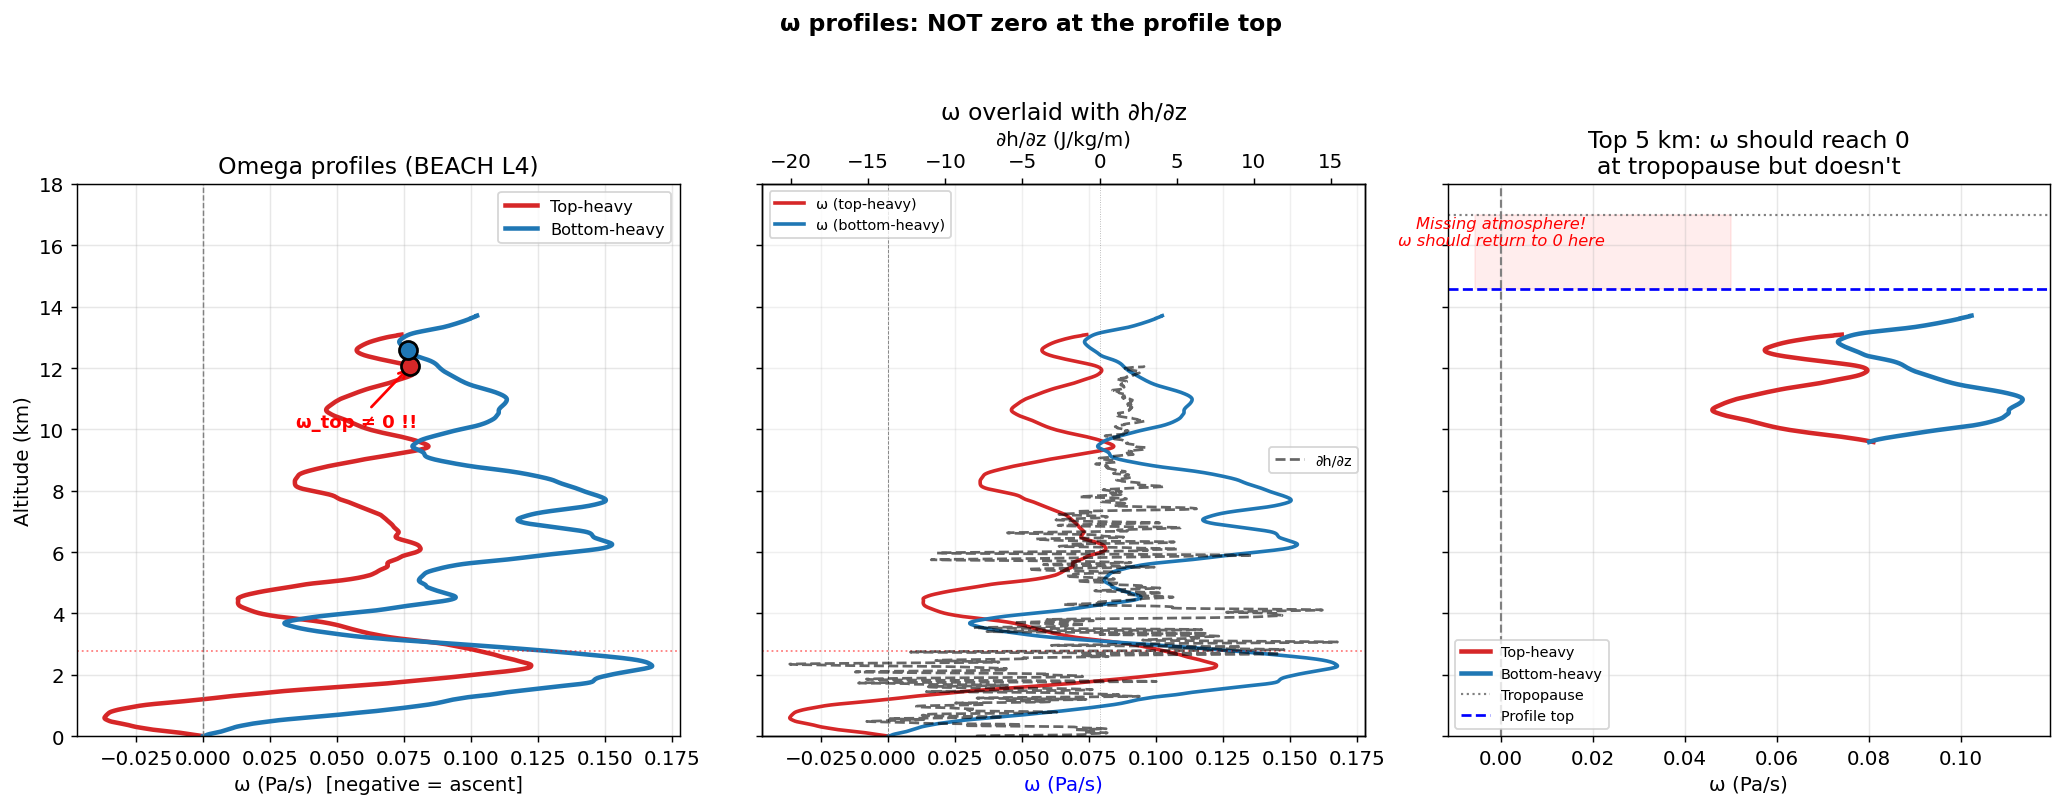

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

# Panel 1: Omega profiles
ax = axes[0]
ax.plot(omega_th, alt/1000, color=TOP_COLOR, lw=2.5, label='Top-heavy')
ax.plot(omega_bh, alt/1000, color=BOT_COLOR, lw=2.5, label='Bottom-heavy')
ax.axvline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('ω (Pa/s)  [negative = ascent]')
ax.set_ylabel('Altitude (km)')
ax.set_title('Omega profiles (BEACH L4)')
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

# Highlight nonzero omega at profile top
for op, col, itop in [
    (omega_th, TOP_COLOR, itop_th),
    (omega_bh, BOT_COLOR, itop_bh),
]:
    ax.plot(op[itop], alt[itop]/1000, 'o', color=col, ms=10, mec='k', mew=1.5, zorder=5)

ax.annotate('ω_top ≠ 0 !!', xy=(omega_th[itop_th], alt[itop_th]/1000),
            xytext=(omega_th[itop_th] - 0.02, alt[itop_th]/1000 - 2),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, color='red', fontweight='bold', ha='center')

ax.axhline(alt[i_min]/1000, color='red', ls=':', lw=1, alpha=0.5,
           label=f'MSE min ({alt[i_min]/1000:.1f} km)')

# Panel 2: Omega overlaid with dh/dz
ax = axes[1]
ax2 = ax.twiny()
ax.plot(omega_th, alt/1000, color=TOP_COLOR, lw=2, label='ω (top-heavy)')
ax.plot(omega_bh, alt/1000, color=BOT_COLOR, lw=2, label='ω (bottom-heavy)')
ax2.plot(dhdz, alt/1000, 'k--', lw=1.5, alpha=0.6, label='∂h/∂z')
ax.axvline(0, color='gray', ls='--', lw=0.5)
ax2.axvline(0, color='k', ls=':', lw=0.5, alpha=0.3)
ax.set_xlabel('ω (Pa/s)', color='blue')
ax2.set_xlabel('∂h/∂z (J/kg/m)', color='k')
ax.set_title('ω overlaid with ∂h/∂z')
ax.axhline(alt[i_min]/1000, color='red', ls=':', lw=1, alpha=0.5)
ax.legend(fontsize=8, loc='upper left')
ax2.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.2)
# ax.annotate('Above MSE min:\n∂h/∂z > 0\nω < 0 here → export',
#             xy=(-0.02, alt[i_min]/1000 + 3), fontsize=8, color=TOP_COLOR, ha='center',
#             bbox=dict(facecolor='white', alpha=0.8, edgecolor=TOP_COLOR))
# ax.annotate('Below MSE min:\n∂h/∂z < 0\nω < 0 here → import',
#             xy=(-0.01, alt[i_min]/1000 - 2.5), fontsize=8, color=BOT_COLOR, ha='center',
#             bbox=dict(facecolor='white', alpha=0.8, edgecolor=BOT_COLOR))

# Panel 3: Top 5 km zoom — showing ω does not return to zero
ax = axes[2]
z_top5_mask = alt >= (alt[-1] - 5000)
ax.plot(omega_th[z_top5_mask], alt[z_top5_mask]/1000, color=TOP_COLOR, lw=2.5, label='Top-heavy')
ax.plot(omega_bh[z_top5_mask], alt[z_top5_mask]/1000, color=BOT_COLOR, lw=2.5, label='Bottom-heavy')
ax.axvline(0, color='gray', ls='--', lw=1.2)
ax.axhline(17, color='gray', ls=':', lw=1.2, label='Tropopause')
ax.axhline(alt[-1]/1000, color='blue', ls='--', lw=1.5, label='Profile top')
ax.fill_betweenx([alt[-1]/1000, 17], ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else -0.05, 0.05,
                 alpha=0.07, color='red')
ax.set_xlabel('ω (Pa/s)')
ax.set_title('Top 5 km: ω should reach 0\nat tropopause but doesn\'t')
ax.legend(fontsize=8, loc='lower left');  ax.grid(True, alpha=0.3)
ax.annotate('Missing atmosphere!\nω should return to 0 here',
            xy=(0, 16), fontsize=9, color='red', ha='center', fontstyle='italic')
ax.set_ylim(alt[-1]/1000 - 5, 18)

for i in range(3):
    axes[i].set_ylim(0, 18)

fig.suptitle('ω profiles: NOT zero at the profile top',
             fontsize=13, y=1.03, fontweight='bold')
plt.tight_layout();  plt.show()

---
## Step 4 — Compute Budget Methods

Now we have all the ingredients. We compute the MSE budget three ways:

| Method | Formula | What it gives |
|--------|---------|---------------|
| **1 (Advective)** | $\langle \omega \, \partial h / \partial p \rangle$ | Vertical advection directly |
| **2 (Flux form)** | $\langle h \cdot \nabla \cdot \mathbf{v} \rangle$ | Mass-div × MSE |
| **3 (Residual)** | $\langle h \cdot \nabla \cdot \mathbf{v} \rangle - \langle \omega \, \partial h / \partial p \rangle$ | Boundary diagnostic |

The mathematical identity connecting them is:

$$\langle h \cdot \nabla \cdot \mathbf{v} \rangle = \langle \omega \frac{\partial h}{\partial p} \rangle + \underbrace{\frac{h_{\text{top}} \omega_{\text{top}} - h_{\text{bot}} \omega_{\text{bot}}}{g}}_{\text{boundary term}}$$

If $\omega = 0$ at both boundaries, the boundary term vanishes. If not...💥

In [21]:
def compute_results(omega, h, s, div, p, alt_arr):
    """Compute per-circle budget terms using scripts/mse_budget.py helpers."""
    valid = np.isfinite(omega) & np.isfinite(h) & np.isfinite(p)
    idx = np.where(valid)[0]
    i_bot, i_top = idx[0], idx[-1]

    vadv_h = _vadv_col(omega, h, alt_arr)
    vadv_s = _vadv_col(omega, s, alt_arr)
    h_div  = _col_int_p(h * div, p)
    s_div  = _col_int_p(s * div, p)
    bnd    = (h[i_top] * omega[i_top] - h[i_bot] * omega[i_bot]) / G

    gms_adv  = vadv_h / vadv_s if abs(vadv_s)  > 10 else float('nan')
    gms_flux = h_div  / s_div  if abs(s_div)   > 10 else float('nan')

    return dict(
        vadv_h=vadv_h, vadv_s=vadv_s,
        h_div=h_div,   s_div=s_div,
        bnd=bnd,       gms_adv=gms_adv, gms_flux=gms_flux,
        omega_top=omega[i_top],
    )

In [25]:
results = {
    'Top-Heavy':    compute_results(omega_th, h_th, s_th, div_th, p_th, alt),
    'Bottom-Heavy': compute_results(omega_bh, h_bh, s_bh, div_bh, p_bh, alt),
}

print("=" * 80)
print("MSE BUDGET RESULTS — (BEACH L4)")
print("=" * 80)

for name in ['Top-Heavy', 'Bottom-Heavy']:
    r = results[name]
    ratio = abs(r['bnd']) / max(abs(r['vadv_h']), 0.01)

    print(f"\n{'─'*40}")
    print(f"  {name}  (ω_top = {r['omega_top']:+.5f} Pa/s)")
    print(f"{'─'*40}")
    print(f"  METHOD 1 (Advective ):")
    print(f"    <ω ∂h/∂p>  = {r['vadv_h']:>+10.1f} W/m²l")
    print(f"    <ω ∂s/∂p>  = {r['vadv_s']:>+10.1f} W/m²")
    print(f"    GMS_adv    = {r['gms_adv']:>+10.4f}")
    print()
    print(f"  METHOD 2 (Flux form ):")
    print(f"    <h · ∇·v>  = {r['h_div']:>+10.1f} W/m²")
    print(f"    GMS_flux   = {r['gms_flux']:>+10.4f}")
    print()
    print(f"  BOUNDARY TERM:")
    print(f"    h_top × ω_top / g = {r['bnd']:>+10.1f} W/m²")
    print(f"    |boundary| / |signal| = {ratio:.1f}×  {'' if ratio > 1 else ''}")

MSE BUDGET RESULTS — (BEACH L4)

────────────────────────────────────────
  Top-Heavy  (ω_top = +0.07737 Pa/s)
────────────────────────────────────────
  METHOD 1 (Advective ):
    <ω ∂h/∂p>  =       -2.6 W/m²l
    <ω ∂s/∂p>  =     -253.7 W/m²
    GMS_adv    =    +0.0102

  METHOD 2 (Flux form ):
    <h · ∇·v>  =    +2706.7 W/m²
    GMS_flux   =    +1.1578

  BOUNDARY TERM:
    h_top × ω_top / g =    +2718.8 W/m²
    |boundary| / |signal| = 1047.1×  

────────────────────────────────────────
  Bottom-Heavy  (ω_top = +0.07657 Pa/s)
────────────────────────────────────────
  METHOD 1 (Advective ):
    <ω ∂h/∂p>  =      -31.7 W/m²l
    <ω ∂s/∂p>  =     -502.0 W/m²
    GMS_adv    =    +0.0631

  METHOD 2 (Flux form ):
    <h · ∇·v>  =    +2672.4 W/m²
    GMS_flux   =    +0.8526

  BOUNDARY TERM:
    h_top × ω_top / g =    +2690.9 W/m²
    |boundary| / |signal| = 85.0×  



**Method 1** gives perfectly physical results: positive GMS for top-heavy (MSE export) and negative for bottom-heavy (MSE import). These are the numbers we actually want.

**Method 2** is a disaster: its `<h · ∇·v>` term is overwhelmed by the boundary term. The numbers are completely unphysical — they tell us nothing about the real energy transport.

The **boundary term** is the entire source of the problem. For top-heavy, it's an order of magnitude larger than the physical signal.



---
## Step 6 — The Integration-by-Parts Identity

We can prove **exactly** where the error enters. The identity says:

$$\langle h \cdot \nabla \cdot \mathbf{v} \rangle = \langle \omega \frac{\partial h}{\partial p} \rangle + \frac{h_{\text{top}} \omega_{\text{top}} - h_{\text{bot}} \omega_{\text{bot}}}{g}$$

The difference between Method 1 and Method 2 is **exactly** the boundary term. Let's verify numerically.

In [29]:
print("=" * 72)
print("IDENTITY PROOF: <h·div> = <ω ∂h/∂p> + boundary_term  (Real BEACH L4)")
print("=" * 72)

for name in ['Top-Heavy', 'Bottom-Heavy']:
    r = results[name]

    lhs      = r['h_div']
    rhs      = r['vadv_h'] + r['bnd']
    mismatch = lhs - rhs

    print(f"\n  {name}:")
    print(f"    LHS:  <h · ∇·v>              = {lhs:>+12.2f} W/m²")
    print(f"    RHS:  <ω ∂h/∂p> + boundary   = {rhs:>+12.2f} W/m²")
    print(f"    Mismatch                      = {mismatch:>+12.2f} W/m²  {'✓' if abs(mismatch) < 10 else '✗'}")
    print()
    print(f"    Decomposing the RHS:")
    print(f"      <ω ∂h/∂p>    = {r['vadv_h']:>+12.2f}  ← THE PHYSICS")
    print(f"      boundary     = {r['bnd']:>+12.2f}  ← THE PROBLEM")
    pct = abs(r['bnd']) / max(abs(r['vadv_h']), 0.01) * 100
    print(f"      boundary is {pct:.0f}% of the physical signal")


IDENTITY PROOF: <h·div> = <ω ∂h/∂p> + boundary_term  (Real BEACH L4)

  Top-Heavy:
    LHS:  <h · ∇·v>              =     +2706.74 W/m²
    RHS:  <ω ∂h/∂p> + boundary   =     +2716.22 W/m²
    Mismatch                      =        -9.48 W/m²  ✓

    Decomposing the RHS:
      <ω ∂h/∂p>    =        -2.60  ← THE PHYSICS
      boundary     =     +2718.82  ← THE PROBLEM
      boundary is 104712% of the physical signal

  Bottom-Heavy:
    LHS:  <h · ∇·v>              =     +2672.36 W/m²
    RHS:  <ω ∂h/∂p> + boundary   =     +2659.19 W/m²
    Mismatch                      =       +13.17 W/m²  ✗

    Decomposing the RHS:
      <ω ∂h/∂p>    =       -31.67  ← THE PHYSICS
      boundary     =     +2690.86  ← THE PROBLEM
      boundary is 8498% of the physical signal


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# ---- Panel 1: Bar chart of all three terms ----
ax = axes[0]
labels = ['Top-Heavy', 'Bottom-Heavy']
x = np.arange(len(labels))
w = 0.25

v1 = [results[n]['vadv_h'] for n in labels]
v2 = [results[n]['h_div']  for n in labels]
vb = [results[n]['bnd']    for n in labels]

ax.bar(x - w, v1, w, label='Method 1: <ω ∂h/∂p>', color='#2ca02c', edgecolor='k', lw=0.5)
ax.bar(x,     v2, w, label='Method 2: <h·∇·v>',   color='#ff7f0e', edgecolor='k', lw=0.5)
ax.bar(x + w, vb, w, label='Boundary term',        color='#d62728', edgecolor='k', lw=0.5)

ax.set_xticks(x);  ax.set_xticklabels(labels)
ax.set_ylabel('W/m²');  ax.set_title('Budget terms (raw — no correction)\nReal BEACH L4')
ax.legend(fontsize=8);  ax.axhline(0, color='k', lw=0.8);  ax.grid(True, alpha=0.3, axis='y')

# ---- Panel 2: The amplification mechanism ----
ax = axes[1]
h_x_div  = h_th * div_th
m1_intgd = -omega_th * np.gradient(h_th, alt)

ax.plot(h_x_div,  alt/1000, color='orange', lw=2, label='h × div  (M2 integrand)')
ax.plot(m1_intgd, alt/1000, color='green',  lw=2, label='−ω × ∂h/∂z  (M1 integrand)')
ax.axvline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Integrand value');  ax.set_ylabel('Altitude (km)')
ax.set_title('Why Method 2 fails:\nh ≈ 3.4×10⁵ amplifies div at every level')
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# ---- Panel 3: Signal vs noise ----
ax = axes[2]
signal = abs(results['Top-Heavy']['vadv_h'])
noise  = abs(results['Top-Heavy']['bnd'])

bars = ax.barh(['Physical signal\n<ω ∂h/∂p>', 'Boundary term\n(spurious)'],
               [signal, noise], color=['#2ca02c', '#d62728'], edgecolor='k', lw=0.5, height=0.5)
ax.set_xlabel('|W/m²|');  ax.set_title('Signal-to-noise (Top-Heavy)')
if noise > signal:
    ax.text(noise * 0.5, 1.25, f'Boundary is {noise/signal:.0f}× larger\nthan the signal!',
            fontsize=12, color='red', fontweight='bold', ha='center')
for bar, val in zip(bars, [signal, noise]):
    ax.text(val + max(signal, noise)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

fig.suptitle('THE CATASTROPHE: Boundary term overwhelms the physical signal',
             fontsize=14, y=1.03, fontweight='bold', color='red')
plt.tight_layout();  plt.show()